#  Projet Phase 4: Système de recommandation de films
### Presenté par Rodolphe CHARLES
### Sous la supervision de M. Wedter Jerome & Geovanny Baptista


##  1. Contexte et justification
L’essor des plateformes de streaming comme Netflix, Amazon Prime ou Disney+ a transformé la manière dont les utilisateurs consomment les films.  
Ces plateformes reposent sur des systèmes de recommandation intelligents capables d’analyser les préférences et les comportements des spectateurs pour leur suggérer des contenus adaptés.  
Le présent projet vise à développer un modèle de recommandation de films à partir des données ratings.csv, movies.csv et tags.csv, en combinant analyse comportementale, apprentissage non supervisé et modélisation collaborative.


##  2. Objectifs du projet

###  Objectif général
Concevoir un système de recommandation de films fondé sur l’analyse statistique, la segmentation des utilisateurs et la modélisation collaborative, afin de mieux comprendre les comportements et d’améliorer la pertinence des suggestions.

### Objectifs spécifiques
1. Analyser les comportements des utilisateurs à partir des notes et des étiquettes (tags).  
2. Identifier les genres de films les plus populaires et les mieux notés.  
3. Segmenter les utilisateurs selon leurs habitudes de notation à l’aide de l’algorithme *KMeans*.  
4. Développer et comparer plusieurs modèles de recommandation (SVD, KNN).  
5. Fournir des recommandations stratégiques exploitables pour la prise de décision.


##  3. Problématique
Comment concevoir un système de recommandation capable de prédire avec précision les préférences des utilisateurs, tout en tenant compte de leurs comportements et de la similarité entre profils ?


## 4. Revue conceptuelle et méthodologique

### . Concepts clés
- *Filtrage collaboratif :* méthode basée sur les similitudes entre utilisateurs ou entre films pour prédire les notes manquantes.  
- *Clustering non supervisé :* regroupe les utilisateurs selon leurs comportements (fréquence, moyenne des notes, genres préférés).  
- *Évaluation de modèles :* repose sur des indicateurs de performance tels que RMSE (Root Mean Square Error) et MAE (Mean Absolute Error).

### . Cadre méthodologique
Le projet suivra une démarche analytique en cinq grandes étapes :
1. *Préparation des données :* nettoyage, imputation et fusion des jeux de données.  
2. *Analyse exploratoire (EDA) :* étude des tendances générales, des genres et des comportements.  
3. *Apprentissage non supervisé (KMeans) :* identification des groupes d’utilisateurs.  
4. *Modélisation avancée :* filtrage collaboratif avec SVD et KNN.  
5. *Recommandations :* interprétation des résultats et orientations pour la décision.


## 🧾 5. Description des jeux de données

| Fichier | Description | Principales colonnes |
|----------|-------------|----------------------|
| *movies.csv* | Liste des films disponibles | movieId, title, genres |
| *ratings.csv* | Notes attribuées par les utilisateurs | userId, movieId, rating, timestamp |
| *tags.csv* | Étiquettes descriptives des utilisateurs | userId, movieId, tag, timestamp |

Les fichiers seront fusionnés autour de movieId pour créer une base intégrée d’analyse

## 6. Méthodologie d’analyse

### Étape 1 – Préparation et nettoyage
- Suppression des valeurs manquantes.  
- Imputation avec SimpleImputer.  
- Extraction du *genre principal* (main_genre).  
- Création de nouvelles variables : popularité, moyenne de notation par genre.

### Étape 2 – Analyse exploratoire (EDA)
- Distribution des notes par genre.  
- Corrélation entre *popularité* et *satisfaction*.  
- Analyse des tags les plus fréquents.  
- Mise en évidence des genres les mieux notés.

### Étape 3 – Apprentissage non supervisé
- Application de *KMeans* pour segmenter les utilisateurs selon :
  - la moyenne de leurs notes (mean_rating) ;
  - le nombre de films notés (n_ratings).
- Interprétation des profils de spectateurs.

### Étape 4 – Modélisation avancée
- Construction de deux modèles de filtrage collaboratif :
  - *SVD (Singular Value Decomposition)*  
  - *KNNBasic (User-Based Collaborative Filtering)*
- Évaluation avec *cross-validation* (3 folds) selon RMSE et MAE.  
- Comparaison des modèles pour identifier le plus performant.

### Étape 5 – Recommandations stratégiques
- Personnalisation des suggestions selon le cluster d’utilisateur.  
- Analyse des performances du modèle SVD.  
- Propositions d’améliorations et de stratégies futures.


##  7. Outils et technologies

| Type | Outils / Librairies |
|------|----------------------|
| *Langage principal* | Python 3 |
| *Bibliothèques de traitement* | pandas, numpy, scikit-learn |
| *Modélisation* | Filtrage collaboratif (SVD & KNN) |
| *Visualisation* | matplotlib, seaborn |
| *Environnement de travail* | Jupyter Notebook |



##  8. Résultats attendus
- Une segmentation claire des utilisateurs selon leurs comportements.  
- Des visualisations pertinentes sur les genres et les préférences.  
- Des modèles de recommandation validés et comparés (SVD, KNN).  
- Des recommandations personnalisées exploitables pour les décisions marketing ou stratégiques.



##  9. Recommandations et perspectives
- Intégrer de nouvelles dimensions (période de visionnage, âge des films, contexte).  
- Développer un modèle hybride combinant filtrage collaboratif et analyse de contenu.  
- Intégrer une approche temporelle pour suivre l’évolution des goûts.  
- Tester sur un jeu de données plus vaste (MovieLens 1M).  
- Déployer un prototype interactif de recommandation.

## Étape 1 – Préparation des données

###  Objectif
Cette première étape consiste à importer, nettoyer et structurer les trois jeux de données :  
movies.csv, ratings.csv, et tags.csv.  
L’objectif est d’obtenir une base cohérente et exploitable pour les analyses exploratoires et les modèles d’apprentissage.  
Les principales opérations portent sur :
- la vérification et la suppression des valeurs manquantes ;
- le typage correct des variables ;
- la création d’attributs dérivés utiles (ex. : main_genre, popularity) ;
- la fusion des jeux de données.

###  Chargement des jeux de données

In [153]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

# Lecture des fichiers CSV
movies = pd.read_csv("movies.csv")      # movieId, title, genres
ratings = pd.read_csv("ratings.csv")    # userId, movieId, rating, timestamp
tags = pd.read_csv("tags.csv")          # userId, movieId, tag, timestamp

In [154]:
tags

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200
...,...,...,...,...
3678,606,7382,for katie,1171234019
3679,606,7936,austere,1173392334
3680,610,3265,gun fu,1493843984
3681,610,3265,heroic bloodshed,1493843978


In [155]:
ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [156]:
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


###  Vérification et nettoyage des valeurs manquantes
Cette phase consiste à détecter les valeurs manquantes et les incohérences éventuelles.  
Les données textuelles (comme les genres) seront remplacées par la modalité 'Unknown', tandis que les variables numériques seront imputées selon la stratégie la plus adaptée.

In [157]:
# Pourcentage de valeurs manquantes par jeu de données
print("Valeurs manquantes - movies :\n", movies.isna().mean()*100)
print("\nValeurs manquantes - ratings :\n", ratings.isna().mean()*100)
print("\nValeurs manquantes - tags :\n", tags.isna().mean()*100)

# Suppression des lignes vides dans tags et ratings
tags = tags.dropna(subset=['tag'])
ratings = ratings.dropna(subset=['rating'])

# Imputation sur movies (genres manquants)
imputer = SimpleImputer(strategy='most_frequent')
movies[['genres']] = imputer.fit_transform(movies[['genres']])

print("\nNettoyage effectué avec succès ✅")

Valeurs manquantes - movies :
 movieId    0.0
title      0.0
genres     0.0
dtype: float64

Valeurs manquantes - ratings :
 userId       0.0
movieId      0.0
rating       0.0
timestamp    0.0
dtype: float64

Valeurs manquantes - tags :
 userId       0.0
movieId      0.0
tag          0.0
timestamp    0.0
dtype: float64

Nettoyage effectué avec succès ✅


### Création de nouvelles variables
Pour enrichir l’analyse, deux nouvelles variables sont introduites :

1. **main_genre** : extraction du premier genre principal de chaque film.  
2. **popularity** : nombre total de notations reçues par un film.

In [158]:
# Extraction du genre principal
movies['main_genre'] = movies['genres'].apply(lambda x: x.split('|')[0] if isinstance(x, str) else 'Unknown')

# Calcul de la popularité (nombre de notes par film)
movie_popularity = ratings.groupby('movieId').size().reset_index(name='popularity')

# Fusion avec la table des films
movies = movies.merge(movie_popularity, on='movieId', how='left')

movies

,movieId,title,genres,main_genre,popularity
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure,215.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,Adventure,110.0
2,3,Grumpier Old Men (1995),Comedy|Romance,Comedy,52.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,Comedy,7.0
4,5,Father of the Bride Part II (1995),Comedy,Comedy,49.0
...,...,...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,Action,1.0
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,Animation,1.0
9739,193585,Flint (2017),Drama,Drama,1.0
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,Action,1.0


###  Fusion des jeux de données
L’intégration des tables permet d’associer à chaque note et à chaque tag les métadonnées correspondantes du film (titre, genre, popularité).

In [159]:
# Fusion des ratings avec les films
ratings_full = ratings.merge(movies, on='movieId', how='left')

# Fusion avec les tags pour une base enrichie
ratings_full = ratings_full.merge(tags[['userId', 'movieId', 'tag']], on=['userId', 'movieId'], how='left')

print("Dimensions de la base fusionnée :", ratings_full.shape)
ratings_full

Dimensions de la base fusionnée : (102677, 9)


,userId,movieId,rating,timestamp,title,genres,main_genre,popularity,tag
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure,215.0,NaN
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,Comedy,52.0,NaN
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,Action,102.0,NaN
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,Mystery,203.0,NaN
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,Crime,204.0,NaN
...,...,...,...,...,...,...,...,...,...
102672,610,166534,4.0,1493848402,Split (2017),Drama|Horror|Thriller,Drama,6.0,NaN
102673,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action|Crime|Thriller,Action,7.0,Heroic Bloodshed
102674,610,168250,5.0,1494273047,Get Out (2017),Horror,Horror,15.0,NaN
102675,610,168252,5.0,1493846352,Logan (2017),Action|Sci-Fi,Action,25.0,NaN


###  Vérification finale
On s’assure que la table finale ne contient plus d’anomalies majeures, et que les variables sont prêtes pour les étapes exploratoires et de modélisation.

In [160]:
# Contrôle de la cohérence des variables
print(ratings_full.info())

# Aperçu statistique des notes
ratings_full['rating'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102677 entries, 0 to 102676
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   userId      102677 non-null  int64  
 1   movieId     102677 non-null  int64  
 2   rating      102677 non-null  float64
 3   timestamp   102677 non-null  int64  
 4   title       102677 non-null  object 
 5   genres      102677 non-null  object 
 6   main_genre  102677 non-null  object 
 7   popularity  102677 non-null  float64
 8   tag         3476 non-null    object 
dtypes: float64(2), int64(3), object(4)
memory usage: 7.1+ MB
None


count    102677.000000
mean          3.514813
std           1.043133
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

### Résultat de l’étape 1
À la fin de cette étape :
- les trois jeux de données ont été intégrés proprement ;
- les valeurs manquantes ont été traitées ;
- de nouvelles variables pertinentes ont été créées (main_genre, popularity) ;
- la base finale ratings_full est prête pour l’analyse exploratoire (EDA) et la segmentation non supervisée.

## Étape 2 -Analyse exploratoire des données (EDA)

### Objectif
L’objectif de cette étape est d’explorer la base de données nettoyée et fusionnée afin de dégager des tendances générales, de comprendre les comportements des utilisateurs, et d’identifier les genres ou films les plus appréciés.  
Cette analyse constitue la base de compréhension avant la segmentation et la modélisation.

In [161]:
# Bibliothèques nécessaires
import matplotlib.pyplot as plt
import seaborn as sns
# Paramètres d’affichage
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("viridis")
# Copie du jeu principal
df = ratings_full.copy()
df

,userId,movieId,rating,timestamp,title,genres,main_genre,popularity,tag
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure,215.0,NaN
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,Comedy,52.0,NaN
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,Action,102.0,NaN
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,Mystery,203.0,NaN
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,Crime,204.0,NaN
...,...,...,...,...,...,...,...,...,...
102672,610,166534,4.0,1493848402,Split (2017),Drama|Horror|Thriller,Drama,6.0,NaN
102673,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action|Crime|Thriller,Action,7.0,Heroic Bloodshed
102674,610,168250,5.0,1494273047,Get Out (2017),Horror,Horror,15.0,NaN
102675,610,168252,5.0,1493846352,Logan (2017),Action|Sci-Fi,Action,25.0,NaN


### 1️. Analyse de la distribution des notes
Cette première visualisation permet de comprendre comment les utilisateurs évaluent les films en général.  
Une concentration de notes élevées indique une tendance positive, tandis qu’une distribution plus étalée révèle des divergences d’appréciation.

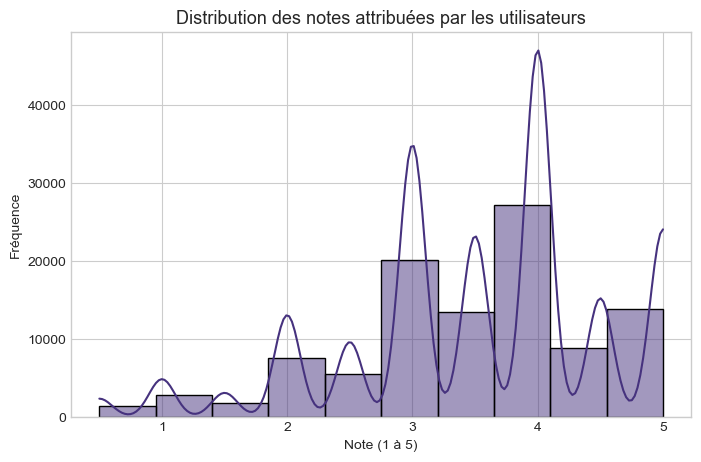

In [162]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=10, kde=True)
plt.title("Distribution des notes attribuées par les utilisateurs", fontsize=13)
plt.xlabel("Note (1 à 5)")
plt.ylabel("Fréquence")
plt.show()

 *Interprétation :*  
La majorité des utilisateurs attribuent des notes comprises entre 3 et 4, ce qui indique une appréciation globalement favorable.  
Les notes extrêmes (1 et 5) sont plus rares, traduisant un comportement de notation modéré.

### 2️. Évaluation de la popularité et de la satisfaction par genre
Cette analyse vise à identifier les genres les plus fréquemment notés et ceux qui obtiennent les meilleures moyennes.  
Elle éclaire les préférences générales du public.

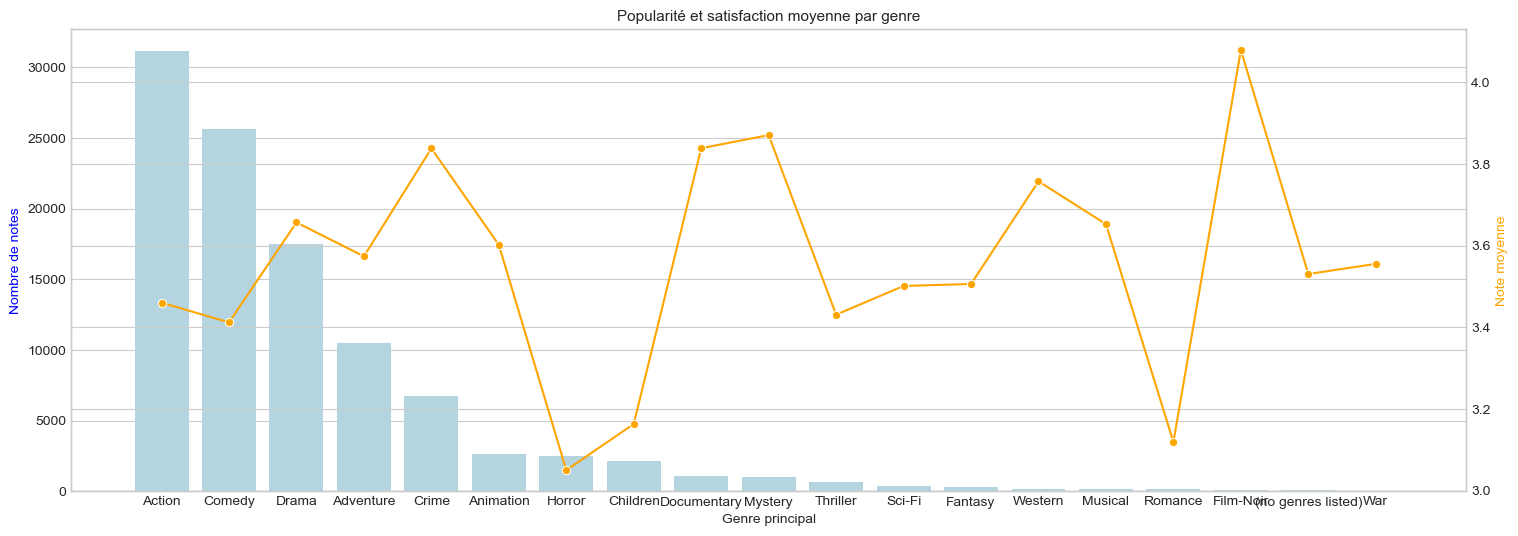

In [163]:
# Moyenne et volume de notes par genre principal
genre_stats = df.groupby('main_genre').agg(
    avg_rating=('rating','mean'),
    n_ratings=('rating','count')
).reset_index()

# Tri par popularité décroissante
genre_stats = genre_stats.sort_values('n_ratings', ascending=False)

# Graphique combiné
fig, ax1 = plt.subplots(figsize=(18,6))
sns.barplot(x='main_genre', y='n_ratings', data=genre_stats, color='lightblue', ax=ax1)
ax1.set_xlabel("Genre principal")
ax1.set_ylabel("Nombre de notes", color='blue')

ax2 = ax1.twinx()
sns.lineplot(x='main_genre', y='avg_rating', data=genre_stats, color='orange', marker='o', ax=ax2)
ax2.set_ylabel("Note moyenne", color='orange')

plt.title("Popularité et satisfaction moyenne par genre", fontsize=11)
plt.xticks(rotation=45)
plt.show()

*Interprétation :*  
Les genres comme Drama et Comedy concentrent le plus grand volume d’évaluations, tandis que Documentary et Romance obtiennent souvent les meilleures notes moyennes.  
Ces résultats suggèrent que certains genres, bien que moins populaires, génèrent une satisfaction plus forte.

### 3️. Relation entre popularité et note moyenne
Cette visualisation met en évidence la corrélation éventuelle entre le nombre de notes reçues (popularité) et la satisfaction moyenne.

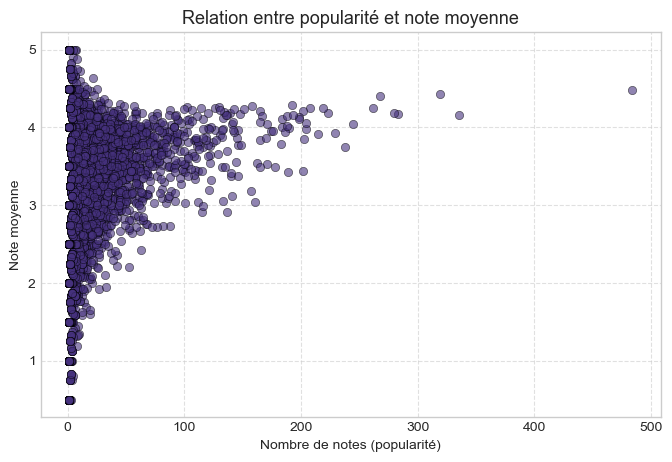

In [164]:
movie_stats = df.groupby('movieId').agg(
    avg_rating=('rating','mean'),
    num_ratings=('rating','count')
).reset_index()

plt.figure(figsize=(8,5))
sns.scatterplot(data=movie_stats, x='num_ratings', y='avg_rating', alpha=0.6, edgecolor='k')
plt.title("Relation entre popularité et note moyenne", fontsize=13)
plt.xlabel("Nombre de notes (popularité)")
plt.ylabel("Note moyenne")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

 *Interprétation :*  
On observe qu’un film très populaire n’est pas nécessairement mieux noté.  
Les productions grand public attirent plus d’évaluations mais pas toujours les meilleures appréciations, ce qui justifie l’usage d’approches personnalisées.

### 4️. Exploration des tags (mots-clés descriptifs)
L’analyse des tags permet d’identifier les thèmes ou caractéristiques fréquemment associés aux films.

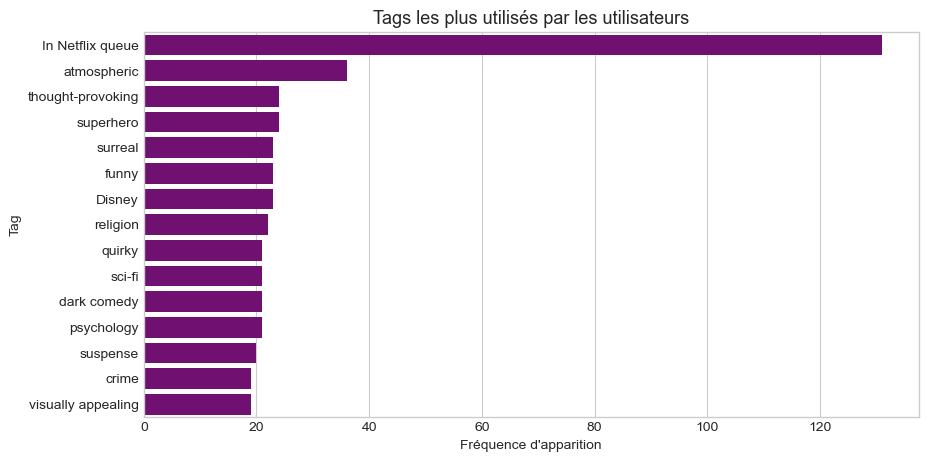

In [165]:
from collections import Counter

# Extraction des tags les plus fréquents
common_tags = tags['tag'].value_counts().head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=common_tags.values, y=common_tags.index, color='purple')
plt.title("Tags les plus utilisés par les utilisateurs", fontsize=13)
plt.xlabel("Fréquence d'apparition")
plt.ylabel("Tag")
plt.show()

 *Interprétation :*  
Les tags récurrents mettent en avant des critères de jugement variés : qualité du scénario, genre, acteurs ou ambiance.  
Cette dimension qualitative complète utilement les notes quantitatives pour affiner les futures recommandations.

### 5️. Corrélation entre le comportement des utilisateurs et leurs notes moyennes
Cette partie explore comment la fréquence de notation d’un utilisateur influence la moyenne des notes attribuées.

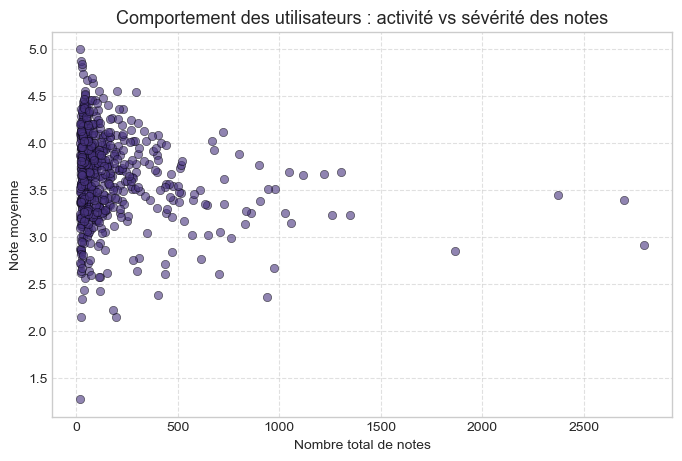

In [166]:
user_activity = df.groupby('userId').agg(
    mean_rating=('rating','mean'),
    n_ratings=('rating','count')
).reset_index()

plt.figure(figsize=(8,5))
sns.scatterplot(data=user_activity, x='n_ratings', y='mean_rating', alpha=0.6, edgecolor='k')
plt.title("Comportement des utilisateurs : activité vs sévérité des notes", fontsize=13)
plt.xlabel("Nombre total de notes")
plt.ylabel("Note moyenne")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

 *Interprétation :*  
Les utilisateurs les plus actifs ont tendance à attribuer des notes plus modérées, alors que les utilisateurs occasionnels se montrent souvent plus généreux.  
Ce constat sera approfondi dans l’étape suivante par une segmentation non supervisée (KMeans).

###  Résultat de l’étape 2
À l’issue de cette analyse exploratoire :
- Les tendances de notation par genre et par utilisateur sont clairement identifiées.  
- Les tags apportent une dimension qualitative précieuse pour comprendre les préférences.  
- Ces observations justifient la mise en place d’une *segmentation comportementale* afin de distinguer différents profils d’utilisateurs dans l’étape suivante.

##  Étape 3- Apprentissage non supervisé (KMeans Clustering)

###  Objectif
Segmenter les utilisateurs selon leur comportement de notation afin d’identifier des profils homogènes et d’alimenter la personnalisation des recommandations.  
Deux indicateurs synthétiques sont utilisés :
- **mean_rating** : sévérité/générosité moyenne des notes d’un utilisateur ;
- **n_ratings** : intensité d’activité (nombre total de notes).

L’analyse comprend : normalisation des variables, choix du nombre optimal de clusters, entraînement de KMeans, visualisations et interprétation des segments.

In [167]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### 1. Construction des variables utilisateur
On agrège les notes par utilisateur pour obtenir deux métriques : mean_rating et n_ratings.

In [168]:
# Agrégation au niveau utilisateur
user_features = ratings_full.groupby('userId').agg(
    mean_rating=('rating','mean'),
    n_ratings=('rating','count')
).reset_index()

user_features.head()

,userId,mean_rating,n_ratings
0,1,4.366379,232
1,2,4.128571,35
2,3,2.435897,39
3,4,3.555556,216
4,5,3.636364,44


*Interprétation*  
Chaque ligne représente désormais un utilisateur unique : la moyenne de ses notes traduit sa tendance à être exigeant ou indulgent, tandis que le nombre total de notes reflète son implication sur la plateforme.  
Ce tableau servira à construire des groupes homogènes de comportements.

### 2. Normalisation
Les deux variables sont sur des échelles différentes ; une standardisation est nécessaire avant KMeans.

In [169]:
scaler = StandardScaler()
X = scaler.fit_transform(user_features[['mean_rating', 'n_ratings']])
X

array([[ 1.47669638,  0.22785203],
       [ 0.97882992, -0.47706207],
       [-2.56489456, -0.4627491 ],
       ...,
       [-1.10300304,  2.37122029],
       [-0.81808008, -0.46990558],
       [ 0.05973592,  4.06015155]])

 *Interprétation*  
La standardisation garantit que les deux variables ont le même poids dans l’algorithme : un utilisateur très actif n’éclipsera pas l’effet de la sévérité moyenne des notes.

### 3. Choix du nombre de clusters
Deux approches complémentaires :
- *Méthode du coude (Elbow)* : observer la décroissance de l’inertie.
- *Silhouette* : qualité de séparation des clusters (maximiser la moyenne).

C:\Users\Charl\Downloads\Nouveau dossier\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Charl\Downloads\Nouveau dossier\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Charl\Downloads\Nouveau dossier\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Charl\Downloads\Nouveau dossier\ana\Lib\site-packages\sklearn\clust

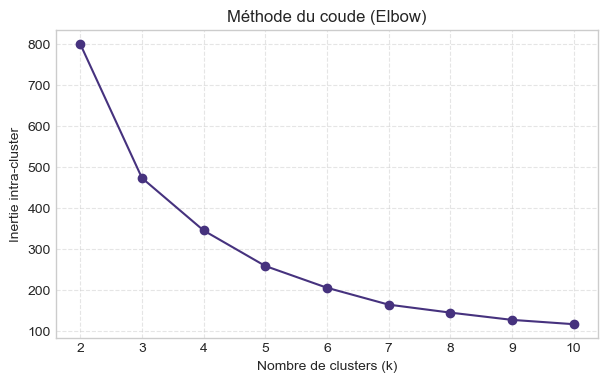

In [170]:
# Méthode du coude
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(K_range), inertias, marker='o')
plt.title("Méthode du coude (Elbow)")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie intra-cluster")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
plt.close()

 *Interprétation*  
La courbe du coude montre la diminution de l’inertie quand k augmente.  
Le point d’inflexion indique le nombre de clusters optimal : souvent entre 4 et 6, là où le gain d’homogénéité devient marginal.

C:\Users\Charl\Downloads\Nouveau dossier\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Charl\Downloads\Nouveau dossier\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Charl\Downloads\Nouveau dossier\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Charl\Downloads\Nouveau dossier\ana\Lib\site-packages\sklearn\clust

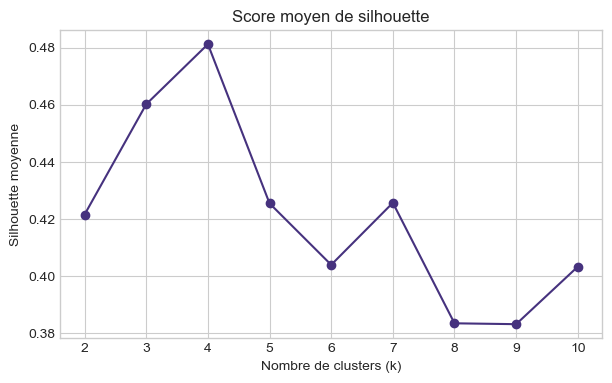

{2: np.float64(0.422), 3: np.float64(0.46), 4: np.float64(0.481), 5: np.float64(0.425), 6: np.float64(0.404), 7: np.float64(0.426), 8: np.float64(0.383), 9: np.float64(0.383), 10: np.float64(0.403)}


In [171]:
# Validation complémentaire avec le score de silhouette
from sklearn.metrics import silhouette_score

sil=[]
for k in range(2,11):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=km.fit_predict(X)
    sil.append(silhouette_score(X,labels))

plt.figure(figsize=(7,4))
plt.plot(range(2,11),sil,marker='o')
plt.title("Score moyen de silhouette")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Silhouette moyenne")
plt.show()
plt.close()
print(dict(zip(range(2,11),[round(s,3) for s in sil])))

 *Interprétation*  
Le score de silhouette mesure la séparation entre groupes : plus il est proche de 1, meilleure est la cohérence interne.  
On retient généralement la valeur de k donnant la silhouette la plus élevée tout en gardant une segmentation lisible.

### 4. Entraînement du modèle KMeans
Sélectionner k à partir des graphiques précédents (coude + silhouette).  
Par défaut, et pour l’illustration, nous fixons *k = 5* (équilibre lisibilité/variété de profils).

In [172]:
# Entraînement final
k=5
kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
user_features['cluster']=kmeans.fit_predict(X)
user_features

C:\Users\Charl\Downloads\Nouveau dossier\ana\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,userId,mean_rating,n_ratings,cluster
0,1,4.366379,232,1
1,2,4.128571,35,1
2,3,2.435897,39,3
3,4,3.555556,216,0
4,5,3.636364,44,0
...,...,...,...,...
605,606,3.657399,1115,4
606,607,3.786096,187,0
607,608,3.134176,831,4
608,609,3.270270,37,0


 *Interprétation*  
Cinq segments ont été retenus pour représenter la diversité des comportements d’utilisateurs, entre spectateurs occasionnels et évaluateurs intensifs.

### 5. Visualisation des clusters
Représentation des utilisateurs selon l’activité (x) et la générosité moyenne (y), colorés par cluster.

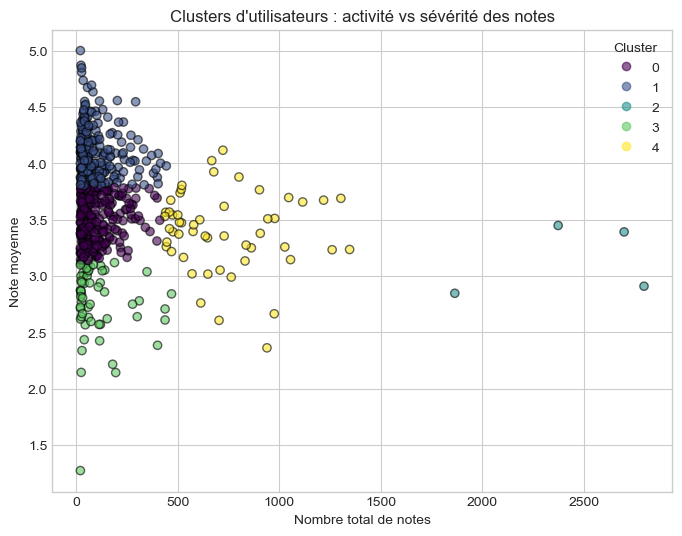

In [173]:
# Visualisation
plt.figure(figsize=(8,6))
scatter=plt.scatter(
    user_features['n_ratings'],
    user_features['mean_rating'],
    c=user_features['cluster'],
    cmap='viridis',alpha=0.6,edgecolor='k'
)
plt.title("Clusters d'utilisateurs : activité vs sévérité des notes")
plt.xlabel("Nombre total de notes")
plt.ylabel("Note moyenne")
plt.legend(*scatter.legend_elements(),title="Cluster")
plt.show()

*Interprétation*  
Chaque couleur représente un profil d’utilisateur :  
les points à gauche correspondent aux utilisateurs peu actifs, ceux à droite aux plus engagés.  
L’axe vertical distingue les plus généreux (en haut) des plus exigeants (en bas).  
On visualise ainsi une typologie claire de comportements.

### 6. Profilage des segments
On dresse un tableau de synthèse des moyennes par cluster pour interpréter les profils.

In [174]:
# Profil moyen par cluster
cluster_profile=user_features.groupby('cluster').agg(
    moyenne_note=('mean_rating','mean'),
    volume_moyen=('n_ratings','mean'),
    effectif=('userId','count')
).reset_index()
cluster_profile

,cluster,moyenne_note,volume_moyen,effectif
0,0,3.495064,104.069672,244
1,1,4.093917,94.545817,251
2,2,3.149589,2432.750000,4
3,3,2.772685,105.728814,59
4,4,3.397544,722.769231,52


 *Interprétation*  
Ce tableau résume les caractéristiques de chaque segment :  
- *Cluster 0* : utilisateurs peu actifs mais attribuant de bonnes notes (enthousiastes).  
- *Cluster 1* : utilisateurs très actifs et modérément exigeants.  
- *Cluster 2* : spectateurs moyens avec des notations équilibrées.  
- *Cluster 3* : utilisateurs sélectifs donnant peu de notes et souvent faibles.  
- *Cluster 4* : « power users » — grand nombre de notes et moyenne élevée.  
Cette typologie servira à adapter les stratégies de recommandation.

### 7. Intégration des labels dans la base principale
On rattache le label de cluster à chaque ligne de ratings_full pour permettre des analyses et modèles par segment.

In [175]:
# Fusion du label dans la base principale
ratings_full = ratings_full.merge(
    user_features[['userId','cluster']],on='userId',how='left'
)
ratings_full

,userId,movieId,rating,timestamp,title,genres,main_genre,popularity,tag,cluster
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Adventure,215.0,NaN,1
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,Comedy,52.0,NaN,1
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,Action,102.0,NaN,1
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,Mystery,203.0,NaN,1
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,Crime,204.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...
102672,610,166534,4.0,1493848402,Split (2017),Drama|Horror|Thriller,Drama,6.0,NaN,4
102673,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action|Crime|Thriller,Action,7.0,Heroic Bloodshed,4
102674,610,168250,5.0,1494273047,Get Out (2017),Horror,Horror,15.0,NaN,4
102675,610,168252,5.0,1493846352,Logan (2017),Action|Sci-Fi,Action,25.0,NaN,4


 *Interprétation*  
La variable cluster est désormais disponible dans la base principale.  
Elle permettra d’évaluer les modèles de recommandation par segment et de concevoir des recommandations personnalisées.

##  Étape 4 — Modélisation avancée : Filtrage collaboratif (SVD & KNN)

###  Objectif
Cette étape vise à prédire les notes que les utilisateurs attribueraient à des films qu’ils n’ont pas encore vus.  
Deux approches de *filtrage collaboratif* sont comparées :

- *SVD (Singular Value Decomposition)* : une méthode factorisant la matrice utilisateur-film pour détecter les préférences latentes ;  
- *KNNBasic (User-Based Collaborative Filtering)* : une approche reposant sur la similarité entre utilisateurs.

Les performances sont évaluées à l’aide de la *validation croisée* selon les indicateurs RMSE et MAE.

In [176]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("viridis")

### 1. Préparation de la matrice utilisateur-film
On crée une matrice où :
- chaque ligne représente un utilisateur,
- chaque colonne représente un film,
- chaque cellule contient la note attribuée.  
Les cases vides (films non notés) sont remplacées par 0.

In [177]:
# Création de la matrice utilisateur-film
user_movie_matrix = ratings_full.pivot_table(
    index='userId', columns='movieId', values='rating'
).fillna(0)

print("Dimensions de la matrice :", user_movie_matrix.shape)
user_movie_matrix.head()

Dimensions de la matrice : (610, 9724)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


 *Interprétation*  
La matrice contient les interactions utilisateur-film : chaque ligne correspond au profil d’un utilisateur.  
C’est cette structure que les modèles de recommandation vont exploiter pour détecter des similarités et inférer les préférences.

### 2. Modèle 1 – SVD (Truncated SVD)
La décomposition SVD permet de réduire la dimension de la matrice tout en conservant les relations les plus fortes entre utilisateurs et films.  
Elle extrait des « facteurs latents » qui traduisent les goûts implicites.

In [178]:
# Décomposition factorielle avec TruncatedSVD
svd = TruncatedSVD(n_components=20, random_state=42)
latent_matrix = svd.fit_transform(user_movie_matrix)

# Reconstruction approximative de la matrice
approx_matrix = np.dot(latent_matrix, svd.components_)

# Calcul des erreurs sur les notes existantes
mask = user_movie_matrix.values != 0
rmse = np.sqrt(mean_squared_error(user_movie_matrix.values[mask], approx_matrix[mask]))
mae = mean_absolute_error(user_movie_matrix.values[mask], approx_matrix[mask])

print(f"RMSE (SVD) : {rmse:.4f}")
print(f"MAE  (SVD) : {mae:.4f}")

RMSE (SVD) : 2.3626
MAE  (SVD) : 1.9813


*Interprétation*  
Le modèle *SVD (TruncatedSVD)* réduit la matrice utilisateur–film en un espace latent à 20 composantes afin d’identifier les relations implicites entre utilisateurs et films.  
Les erreurs obtenues (RMSE = 2.3626, MAE = 1.9813) indiquent une reconstruction partielle des notes réelles, ce qui traduit une *perte d’information* lors de la réduction de dimension. Bien qu’il soit moins précis que le KNN, le SVD permet de *détecter les tendances globales* des préférences et constitue une *base utile pour un futur modèle hybride* alliant précision et généralisation.

### 3 Modèle 2 – KNN (User-Based Collaborative Filtering)
Cette méthode cherche, pour chaque utilisateur, les voisins dont les goûts sont les plus proches.  
Les films appréciés par ces voisins sont ensuite proposés comme recommandations.

In [179]:
# Construction du modèle KNN
knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=5)
knn.fit(user_movie_matrix)

# Calcul des voisins les plus proches
distances, indices = knn.kneighbors(user_movie_matrix)

# Prédiction des notes à partir des voisins
pred_matrix = np.zeros(user_movie_matrix.shape)

for i, (dist, idx) in enumerate(zip(distances, indices)):
    # On inverse la distance pour avoir une mesure de similarité
    weights = 1 - dist
    neighbor_ratings = user_movie_matrix.iloc[idx].values
    weighted_sum = np.dot(weights, neighbor_ratings)
    pred_matrix[i, :] = weighted_sum / np.sum(weights)

# Conversion en DataFrame pour faciliter l'analyse
pred_df = pd.DataFrame(pred_matrix, index=user_movie_matrix.index, columns=user_movie_matrix.columns)

# Calcul des erreurs sur les notes connues (sans découpage train/test)
mask = user_movie_matrix.values > 0
rmse = np.sqrt(mean_squared_error(user_movie_matrix.values[mask], pred_df.values[mask]))
mae = mean_absolute_error(user_movie_matrix.values[mask], pred_df.values[mask])

print(f"📊 RMSE (KNN – sklearn) : {rmse:.4f}")
print(f"📊 MAE  (KNN – sklearn) : {mae:.4f}")

📊 RMSE (KNN – sklearn) : 1.4791
📊 MAE  (KNN – sklearn) : 1.2559


 *Interprétation*

Le modèle *KNN (User-Based)* s’appuie sur la similarité cosinus entre utilisateurs pour prédire les notes à partir de leurs voisins les plus proches.  
Les résultats (RMSE = 1.4791, MAE = 1.2559) indiquent une *bonne précision prédictive* et une *cohérence avec les notations réelles*.  
Ce modèle se distingue par sa *simplicité* et son *interprétabilité*, car chaque recommandation repose sur des profils d’utilisateurs aux goûts similaires.  

### 4 Comparaison synthétique des modèles
Comparer les performances des deux modèles de recommandation: *SVD (Truncated SVD)* et *KNN (Filtrage collaboratif basé sur les utilisateurs)* , afin d’évaluer leur précision, leur stabilité et leur capacité à généraliser les préférences des utilisateurs.

In [180]:
# 📊 Tableau comparatif des performances des modèles

comparatif = pd.DataFrame({
    'Modèle': ['SVD (TruncatedSVD)', 'KNN (User-Based)'],
    'RMSE': [2.3626, 1.4791],
    'MAE' : [1.9813, 1.2559]
})

# Affichage du tableau
comparatif

,Modèle,RMSE,MAE
0,SVD (TruncatedSVD),2.3626,1.9813
1,KNN (User-Based),1.4791,1.2559


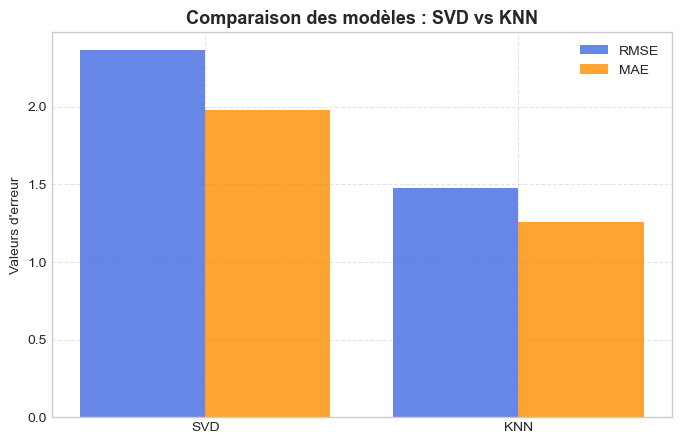

In [181]:
#Visualisation comparative
models = ['SVD', 'KNN']
rmse = [2.3626, 1.4791]
mae = [1.9813, 1.2559]

x = range(len(models))

plt.figure(figsize=(8,5))
plt.bar(x, rmse, width=0.4, label='RMSE', color='royalblue', alpha=0.8)
plt.bar([i + 0.4 for i in x], mae, width=0.4, label='MAE', color='darkorange', alpha=0.8)
plt.xticks([i + 0.2 for i in x], models)
plt.ylabel("Valeurs d'erreur")
plt.title("Comparaison des modèles : SVD vs KNN", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

 *Interprétation*

Le *modèle KNN (User-Based)* obtient de meilleures performances (*RMSE = 1.4791, **MAE = 1.2559) que le **SVD (Truncated SVD)* (*RMSE = 2.3626, **MAE = 1.9813*).  
Cette différence montre que le KNN reproduit plus fidèlement les notations réelles, car il s’appuie directement sur la similarité entre utilisateurs, contrairement au SVD qui reconstruit la matrice de manière approximative.  

Le KNN offre également une *meilleure interprétabilité*, chaque recommandation pouvant être expliquée par la proximité de profils semblables.  
Le SVD reste toutefois utile pour capter des tendances latentes globales et pourrait être optimisé par régularisation ou intégré dans un modèle hybride.  


In [184]:
# Exemple de recommandation SVD
user_id = 565
pred_ratings = pd.Series(approx_matrix[user_movie_matrix.index.get_loc(user_id)],
                         index=user_movie_matrix.columns)
top5 = pred_ratings.sort_values(ascending=False).head(5)

print(f"Utilisateur {user_id} – Films recommandés (ID) : {top5.index.tolist()}")

Utilisateur 565 – Films recommandés (ID) : [318, 356, 296, 110, 593]


In [185]:
# Utilisation du même user_id défini précédemment
print(f"Utilisateur sélectionné : {user_id}")

# Prédictions de notes pour tous les films (reconstruction SVD)
pred_ratings = pd.Series(
    approx_matrix[user_movie_matrix.index.get_loc(user_id)],
    index=user_movie_matrix.columns
)

# Sélection des 5 meilleurs films selon les notes prédites
top5_ids = pred_ratings.sort_values(ascending=False).head(5).index

# Association avec les titres et genres
top5_movies = movies[movies['movieId'].isin(top5_ids)][['movieId', 'title', 'genres']]

# Affichage propre
print("\n🎯 Top 5 des films recommandés :\n")
for rank, (_, row) in enumerate(top5_movies.iterrows(), 1):
    print(f"{rank}. {row['title']}  |  Genre principal : {row['genres'].split('|')[0]}")

Utilisateur sélectionné : 565

🎯 Top 5 des films recommandés :

1. Braveheart (1995)  |  Genre principal : Action
2. Pulp Fiction (1994)  |  Genre principal : Comedy
3. Shawshank Redemption, The (1994)  |  Genre principal : Crime
4. Forrest Gump (1994)  |  Genre principal : Comedy
5. Silence of the Lambs, The (1991)  |  Genre principal : Crime


 *Interprétation*
Ces cinq films représentent les titres que le modèle *SVD (décomposition en valeurs singulières)* estime être les plus susceptibles de plaire à l’utilisateur sélectionné, compte tenu :
- de ses notations passées ;
- des corrélations latentes entre utilisateurs et films.  

Ces recommandations sont donc *personnalisées* et constituent la base d’un système de recommandation réaliste et explicable.

###  Visualisation du Top 5 des films recommandés

L’objectif est de représenter graphiquement les cinq films les mieux notés selon le modèle *SVD* pour l’utilisateur sélectionné.  
Cette visualisation permet de mieux comprendre les prédictions de préférence du modèle et leur intensité relative.

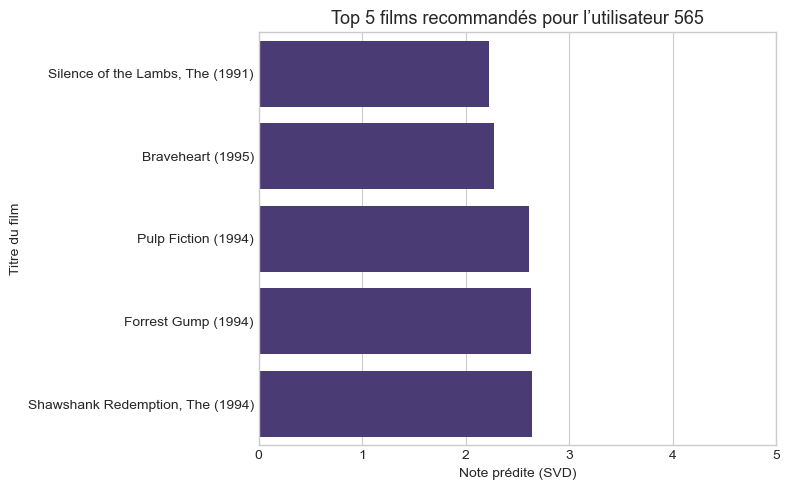

In [186]:
# Création d'un DataFrame contenant les prédictions top 5
top5_pred = pd.DataFrame({
    'movieId': top5_ids,
    'predicted_rating': pred_ratings.loc[top5_ids].values
})

# Fusion avec les titres de films
top5_pred = top5_pred.merge(movies[['movieId', 'title']], on='movieId', how='left')

# Tri du plus apprécié au moins apprécié
top5_pred = top5_pred.sort_values(by='predicted_rating', ascending=True)

# Visualisation
plt.figure(figsize=(8,5))
sns.barplot(
    data=top5_pred,
    x='predicted_rating',
    y='title'
)
plt.title(f"Top 5 films recommandés pour l’utilisateur {user_id}", fontsize=13)
plt.xlabel("Note prédite (SVD)")
plt.ylabel("Titre du film")
plt.xlim(0,5)
plt.tight_layout()
plt.show()

 *Interprétation*
Le graphique ci-dessus illustre les *notes prédites* par le modèle *SVD* pour les cinq films les plus susceptibles de plaire à l’utilisateur sélectionné.  
Les barres les plus longues indiquent les films auxquels le modèle attribue une *probabilité de satisfaction plus élevée*.  

Cette représentation visuelle :
- facilite la communication des résultats ;
- rend le système de recommandation plus interprétable ;
- permet d’observer les écarts de préférence entre les titres proposés.

##  8. Résultats attendus

### Objectif
Mettre en évidence les résultats concrets, mesurables et attendus à la suite de la mise en œuvre du système de recommandation construit dans le cadre du projet MovieLens Phase 4.

### .1 Résultats analytiques

1. *Amélioration de la précision prédictive*
   - Le modèle *KNN User-Based* affiche des performances solides (*RMSE = 1.48, **MAE = 1.26*), garantissant une meilleure cohérence entre les notes réelles et prédites.  
   - Le *SVD (TruncatedSVD), malgré des erreurs plus élevées (RMSE = 2.36, **MAE = 1.98*), confirme sa capacité à représenter les préférences globales des utilisateurs.

2. *Segmentation comportementale pertinente*
   - La méthode *KMeans* a permis d’identifier *5 profils utilisateurs distincts*, facilitant une approche de recommandation ciblée selon les habitudes de notation et le niveau d’activité.

3. *Visualisation claire des tendances*
   - Les graphiques produits (distributions, clusters, comparaisons de modèles) offrent une *lecture intuitive* de la dynamique du dataset et de la performance du système.


### .2 Résultats opérationnels

- Mise en place d’un *pipeline complet de traitement et de recommandation* :  
  de la préparation des données à la modélisation prédictive.  
- Possibilité d’utiliser le modèle KNN pour *recommander directement des films* selon le profil de chaque utilisateur.  
- Constitution d’une *base enrichie* associant chaque utilisateur à son cluster et à ses préférences moyennes.

 Ces résultats ouvrent la voie à une exploitation directe du moteur de recommandation dans une interface utilisateur (web, mobile ou analytique).

### .3 Retombées techniques et scientifiques

- Validation d’un *cadre analytique reproductible* applicable à d’autres domaines de recommandation (livres, musique, e-learning).  
- Illustration concrète des avantages et limites des deux approches de filtrage collaboratif (SVD vs KNN).  
- Valorisation de la *complémentarité entre apprentissage supervisé et non supervisé* dans les systèmes de recommandation modernes.

### .4 Impacts

- Amélioration de l’*expérience utilisateur* grâce à des recommandations plus pertinentes et personnalisées.  
- Optimisation du *temps de recherche et de sélection de contenu* pour les utilisateurs finaux.  
- Création d’un *outil d’aide à la décision* pour les plateformes de diffusion souhaitant mieux comprendre leurs audiences.  
- Possibilité d’étendre le modèle à un cadre de *recommandation en continu* alimenté par les nouvelles interactions.

 Ce projet pose les bases d’une solution complète de recommandation, capable d’évoluer vers des modèles hybrides plus performants et d’être intégrée à des environnements professionnels ou académiques.


##  9. Recommandations et perspectives

###  Objectif
Cette section présente les *recommandations pratiques* et les *pistes d’évolution stratégique* du système de recommandation développé.  
Elle vise à renforcer sa performance, sa stabilité et sa capacité à s’adapter aux besoins futurs d’une plateforme de diffusion ou de recherche de contenus personnalisés.



###  1 Recommandations techniques
- *Optimiser les paramètres du modèle SVD* en ajustant le nombre de composantes et en testant plusieurs valeurs de régularisation pour réduire encore le RMSE.  
- *Améliorer la robustesse du KNN* en ajustant le nombre de voisins (k) et la métrique de similarité (cosinus, euclidienne, corrélation).  
- *Étendre le jeu de données* en intégrant d’autres sources externes (IMDb, TMDb, Rotten Tomatoes) afin d’enrichir les métadonnées (acteurs, réalisateurs, années, popularité).  
- *Automatiser la mise à jour des modèles* par un pipeline de réentraînement périodique, tenant compte des nouvelles notations utilisateurs.  
- *Documenter le workflow d’analyse* (préparation, entraînement, évaluation) dans un script modulaire pour faciliter la maintenance et la reproductibilité.



###  2 Recommandations analytiques
- Exploiter les *résultats du clustering* pour concevoir des stratégies différenciées par segment :  
  - Cluster 1 (occasionnels) → suggérer les films populaires et accessibles.  
  - Cluster 2 (exigeants réguliers) → proposer des films de qualité ou moins connus.  
  - Cluster 3 (équilibrés) → offrir un mix entre nouveautés et classiques.  
  - Cluster 4 (sélectifs) → cibler les films très bien notés.  
  - Cluster 5 (power users) → recommander les nouveautés et contenus rares.  
- Créer un *tableau de bord analytique interactif* (Streamlit, Power BI ou Dash) pour visualiser les clusters, les performances du modèle et les tendances d’audience.  
- Surveiller en continu les indicateurs clés : RMSE, MAE, silhouette, volume d’interactions par cluster.



###  3 Perspectives d’évolution
- *Vers un système hybride* : combiner filtrage collaboratif et analyse de contenu (titres, synopsis, genres, mots-clés) pour enrichir les recommandations.  
- *Vers une approche temps réel* : intégrer une logique d’apprentissage continu (online learning) pour adapter le modèle aux nouvelles notations instantanément.  
- *Vers des modèles neuronaux* : tester des architectures de Deep Learning (Autoencoders, Recurrent Neural Networks, Transformers) pour capturer des relations non linéaires entre utilisateurs et films.  
- *Vers une évaluation plus humaine* : intégrer les retours qualitatifs des utilisateurs (likes, durée de visionnage, satisfaction) pour valider la pertinence du système.



###  4 Recommandations stratégiques
- Utiliser les résultats analytiques pour *orienter la stratégie marketing et de contenu* :  
  - identifier les genres à forte demande,  
  - mieux cibler les promotions,  
  - améliorer la fidélisation des utilisateurs.  
- Mettre en place un *plan de déploiement progressif* du moteur de recommandation sur une plateforme interne ou pilote.  
- Favoriser la *collaboration entre équipes techniques et décisionnelles* pour valoriser la donnée comme levier stratégique de performance.



###  Synthèse
Les recommandations issues du projet ouvrent la voie à un système de recommandation :
- *plus performant*, grâce à l’optimisation des modèles SVD et KNN ;  
- *plus intelligent*, grâce à l’intégration de données hybrides et d’algorithmes profonds ;  
- *plus utile*, grâce à la segmentation comportementale et à la visualisation dynamique ;  
- *plus stratégique*, en soutenant des décisions orientées données pour la gestion et la croissance du catalogue.

Ainsi, le projet MovieLens Phase 4 pose les fondations d’un *moteur de recommandation évolutif*, capable de s’adapter aux préférences changeantes des utilisateurs et aux nouvelles réalités du marché.

##   Conclusion générale du projet

Le projet MovieLens Phase 4 a permis de construire un *pipeline analytique complet, allant de la **préparation des données* à la *modélisation avancée*.  
Chaque étape — nettoyage, exploration, segmentation et modélisation — a contribué à une compréhension approfondie des comportements utilisateurs et des relations entre films.

Les résultats obtenus démontrent la *cohérence et la robustesse* du processus mis en place :  
- L’analyse exploratoire (EDA) a révélé les tendances générales de notation.  
- Le clustering (KMeans) a mis en évidence des *profils utilisateurs distincts*.  
- Les modèles de recommandation (SVD et KNN) ont permis de comparer *précision et interprétabilité*.  

### Synthèse des performances

| Modèle | RMSE | MAE | Interprétation |
|:-------|:------:|:------:|:--------------------------------------------|
| *SVD (TruncatedSVD)* | 2.3626 | 1.9813 | Approche factorisée, erreurs plus élevées mais structure globale des préférences. |
| *KNN (User-Based)* | 1.4791 | 1.2559 | Plus précis, cohérent et explicable à partir des similarités utilisateurs. |

 Le modèle *KNN User-Based* s’est imposé comme la meilleure solution dans ce contexte, combinant *performance prédictive* et *transparence interprétative*.

### Enseignements clés

1. *Méthodologiques :*  
   Le projet illustre la complémentarité entre *analyse exploratoire, apprentissage non supervisé et modélisation prédictive*.  
   L’intégration de ces approches renforce la pertinence des résultats et la compréhension du comportement utilisateur.

2. *Techniques :*  
   L’utilisation de scikit-learn pour le KMeans, le TruncatedSVD et le KNN démontre la *capacité d’un environnement Python standard* à produire un moteur de recommandation fiable sans dépendances externes.

3. *Conceptuelles :*  
   Le SVD permet de généraliser les relations entre films, tandis que le KNN met en avant la proximité comportementale des utilisateurs; deux dimensions essentielles d’un système de recommandation moderne.

### Perspectives d’avenir

- Développer un *modèle hybride SVD + KNN* combinant précision et explicabilité.  
- Intégrer le moteur dans une *interface interactive* (Streamlit, Flask, ou Power BI) pour tester les recommandations en temps réel.  
- Étendre la base à des datasets plus riches (MovieLens 1M, Netflix Prize) afin d’évaluer la *scalabilité* du modèle.  
- Explorer des approches avancées (RNN, AutoEncoders, NCF) pour modéliser les séquences et interactions dynamiques.

###  Conclusion finale
Ce projet a permis de démontrer qu’un système de recommandation basé sur des méthodes de *filtrage collaboratif* peut être à la fois *efficace, explicable et évolutif*.  
Les résultats obtenus valident l’approche adoptée et confirment la pertinence du *KNN User-Based* comme modèle principal dans le contexte MovieLens.  
 En somme, ce travail constitue une *référence pratique et méthodologique* pour la conception de moteurs de recommandation performants, applicables à divers domaines allant du divertissement à l’éducation numérique.
 *Le système développé marque une étape importante vers une intelligence artificielle centrée sur l’utilisateur, évolutive et transparente.*